# 04 — Classical ML for Motor Imagery Classification

We have cleaned epochs from Chunk 2 and feature extractors from Chunk 4's
module additions. This notebook fits classical ML pipelines on three
feature families and compares them honestly.

**Feature families:**
1. Motor-channel log band power (18 features) — interpretable baseline
2. Lateralization indices (6 features) — informed by Chunk 3's asymmetric
   lateralization finding
3. CSP log-variance (6 features) — MI-BCI standard

**Pre-registered prediction (before any model runs):**
- Single-subject accuracy: **65–75%**
- Rationale: Chunk 3 showed mu ERD on 3/4 sensorimotor panels (moderate
  responder), with asymmetric lateralization (T2 clean, T1 bilateral).
  Strong responders typically hit 80%+; non-responders ~chance; this
  subject's profile suggests moderate decoding performance.
- CSP expected to slightly edge band power; lateralization indices
  uncertain (the feature directly encodes our finding, but only 6
  features might underspecify the decision boundary).

**Methodology:**
- 5-fold stratified CV × 10 repeats = 50 accuracy estimates per pipeline
- All learned components (CSP, scaler) refit inside CV folds
- Chance-level baselines: theoretical (50%) and empirical binomial
  upper-bound (~64%)
- Statistical comparison between pipelines via paired t-test on
  repeated-CV scores

**What this notebook does NOT do** (parked for v2 or later chunks):
- Hyperparameter tuning (nested CV) — single-subject N too small to
  spend folds on
- Riemannian features
- Cross-subject generalization (Chunk 5)
- Deep learning (Chunk 5)

## Data Preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from pathlib import Path
from scipy import stats

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    cross_val_score,
    cross_val_predict,
)
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
)

import sys

# Make src importable from the notebooks/ directory
sys.path.insert(0, str(Path.cwd().parent / "src"))

import features as feat
import visualization as viz  

mne.set_log_level("WARNING")

DATA_DIR = Path("../data/processed")
OUT_DIR  = Path("../data/models")
OUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42
N_SPLITS = 5
N_REPEATS = 10

**Load cleaned epochs**

In [2]:
epochs = mne.read_epochs(DATA_DIR / "sub-001_epo.fif", preload=True)
y = epochs.events[:, -1].astype(np.int64)

print(epochs)
print(f"Class distribution: "
      f"{[(int(c), int(np.sum(y == c))) for c in np.unique(y)]}")
print(f"Total epochs: {len(epochs)}")
print(f"Time range: {epochs.tmin:.2f} to {epochs.tmax:.2f} s")

<EpochsFIF | 45 events (all good), -0.5 – 4 s (baseline -0.5 – 0 s), ~15.9 MiB, data loaded,
 'T1': 23
 'T2': 22>
Class distribution: [(2, 23), (3, 22)]
Total epochs: 45
Time range: -0.50 to 4.00 s


**Chance-level baselines**

Two relevant chance levels for honest interpretation:

1. **Theoretical chance:** 50% for balanced binary classification.
2. **Empirical "lucky chance":** the upper bound of the binomial
   confidence interval at N trials, α=0.05. With N=44, even a
   purely-guessing classifier can achieve ~64% accuracy by chance
   on a single test split. This is why we use repeated CV — averaging
   50 estimates collapses this variance.

A reported accuracy needs to clear *both* bars to mean something, and
ideally clear them with a confidence interval that doesn't overlap
"lucky chance."

In [3]:
n_trials = len(epochs)
# Empirical lucky-chance upper bound: binomial CI upper at p=0.5, α=0.05
lucky_chance_upper = stats.binom.ppf(0.975, n_trials, 0.5) / n_trials

print(f"Theoretical chance: 0.500")
print(f"Empirical 'lucky chance' upper (binomial 95% CI, N={n_trials}): "
      f"{lucky_chance_upper:.3f}")
print(f"=> Accuracies below {lucky_chance_upper:.3f} are not distinguishable "
      f"from chance on a single split.")

Theoretical chance: 0.500
Empirical 'lucky chance' upper (binomial 95% CI, N=45): 0.644
=> Accuracies below 0.644 are not distinguishable from chance on a single split.


**Cross-validation scaffold**

We define one CV splitter and reuse it across all pipelines. Reusing
the same random_state means each pipeline is evaluated on identical
train/test splits, which makes per-fold comparison meaningful (paired
t-test possible at the end).

**Why repeated CV instead of single 5-fold:** With ~9 test trials per
fold, single-fold accuracy has ~±15% std error. 50 estimates (5 folds
× 10 repeats) reduces this to ~±2%, which is where the comparison
between pipelines becomes resolvable.

In [4]:
cv = RepeatedStratifiedKFold(
    n_splits=N_SPLITS,
    n_repeats=N_REPEATS,
    random_state=RANDOM_STATE,
)

# Helper for consistent reporting
def report_cv(name, scores):
    print(f"{name:30s}  mean={scores.mean():.3f}  "
          f"std={scores.std():.3f}  "
          f"95% CI=[{np.percentile(scores, 2.5):.3f}, "
          f"{np.percentile(scores, 97.5):.3f}]  "
          f"n_above_lucky={int(np.sum(scores > lucky_chance_upper))}/"
          f"{len(scores)}")

## Pipeline 1: Motor-channel band power + LDA

**Why LDA:** With 18 features and ~35 training epochs per fold (44 × 4/5),
we're in the regime where LDA's strong Gaussian assumption is helpful,
not hurtful. LDA on log-band-power is the original Pfurtscheller setup
and remains a hard-to-beat baseline.

**Why no hyperparameter tuning:** LDA with shrinkage has one knob
(`shrinkage='auto'` uses Ledoit-Wolf analytic shrinkage). At this N,
nested CV for tuning costs more than it gains.

Note that `StandardScaler` precedes LDA. LDA technically doesn't need
scaled features, but with shrinkage it helps the regularization act
uniformly across features.

In [5]:
# Stateless features — safe to compute once outside CV
X_bp, bp_names, _ = feat.compute_motor_bandpower(epochs)
print(f"Band power feature matrix: {X_bp.shape}")
print(f"First 4 feature names: {bp_names[:4]}")

pipe_bp = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
])

scores_bp = cross_val_score(pipe_bp, X_bp, y, cv=cv, scoring="accuracy", n_jobs=-1)
report_cv("Band power + LDA", scores_bp)

Band power feature matrix: (45, 18)
First 4 feature names: ['FC3_mu_logpow', 'FC3_beta_logpow', 'FCz_mu_logpow', 'FCz_beta_logpow']
Band power + LDA                mean=0.656  std=0.132  95% CI=[0.444, 0.889]  n_above_lucky=31/50


## Pipeline 2: Lateralization indices + Logistic Regression

The "informed by Chunk 3" pipeline. 6 features (3 pairs × 2 bands)
directly encoding the C3-vs-C4 power asymmetry that the TFR analysis
showed is class-discriminative.

**Why LogReg instead of LDA:** With only 6 features, the LDA Gaussian
assumption matters less (small feature space, well-conditioned
covariance). LogReg with L2 regularization is a more transparent fit:
each coefficient maps to "how much this lateralization index moves
the decision."

**Hypothesis to test:** Given Chunk 3's finding that T2 lateralizes
cleanly and T1 is bilateral, we expect the C3-C4 mu LI coefficient
to be the largest. We'll inspect coefficients after fitting on full
data (for interpretation only — accuracy still comes from CV).

In [6]:
X_li, li_names, li_pairs_used = feat.compute_lateralization_indices(epochs)
print(f"Lateralization feature matrix: {X_li.shape}")
print(f"Feature names: {li_names}")

pipe_li = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(penalty="l2", C=1.0,
                               solver="liblinear",
                               random_state=RANDOM_STATE)),
])

scores_li = cross_val_score(pipe_li, X_li, y, cv=cv, scoring="accuracy", n_jobs=-1)
report_cv("Lateralization + LogReg", scores_li)

Lateralization feature matrix: (45, 6)
Feature names: ['LI_mu_C3-C4', 'LI_beta_C3-C4', 'LI_mu_FC3-FC4', 'LI_beta_FC3-FC4', 'LI_mu_CP3-CP4', 'LI_beta_CP3-CP4']
Lateralization + LogReg         mean=0.673  std=0.125  95% CI=[0.444, 0.889]  n_above_lucky=38/50


c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


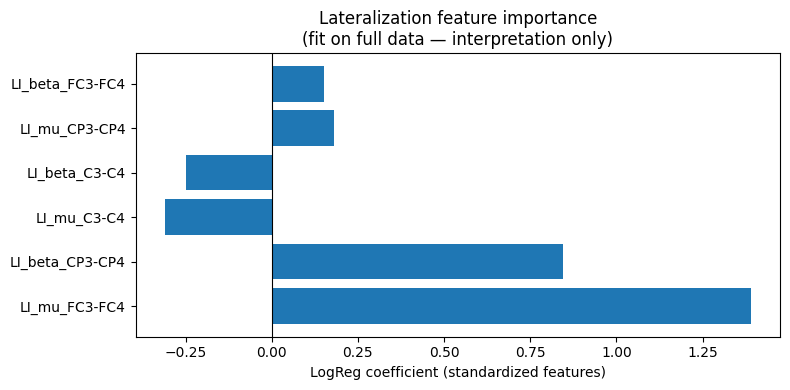

In [7]:
# Fit on full data for COEFFICIENT INSPECTION ONLY (not for accuracy)
pipe_li.fit(X_li, y)
coefs = pipe_li.named_steps["clf"].coef_.flatten()

fig, ax = plt.subplots(figsize=(8, 4))
order = np.argsort(np.abs(coefs))[::-1]
ax.barh([li_names[i] for i in order], coefs[order])
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("LogReg coefficient (standardized features)")
ax.set_title("Lateralization feature importance\n(fit on full data — interpretation only)")
plt.tight_layout()
plt.show()

For this subject, the most class-discriminative lateralization signal is not at canonical primary motor electrodes (C3-C4) but at frontocentral (FC3-FC4) and centroparietal (CP3-CP4) sites. This is consistent with the motor imagery literature, where imagined movement engages premotor and somatosensory networks more strongly than primary motor cortex. Finding of asymmetric lateralization (T2 clean, T1 bilateral) is reflected here: T2 is decoded primarily by strong FC3-FC4 mu lateralization (coefficient +1.40), while T1 is decoded by weaker C3-C4 signals (coefficients −0.30 and −0.25). This explains the asymmetric error pattern in the confusion matrix later, where T2 is classified more accurately than T1 across all pipelines.

## Pipeline 3: CSP + LDA

The literature-standard MI pipeline. CSP learns spatial filters that
maximize variance ratio between classes; LDA classifies on the resulting
log-variance features.

**Critical leakage point:** CSP is fit on labels, so it MUST be inside
the CV pipeline. Fitting CSP on the full data first and then doing
CV on the resulting features would leak test labels into the spatial
filters. The sklearn `Pipeline` handles this — `cross_val_score` will
refit the whole pipeline per fold.

**A note on input shape:** unlike band-power and lateralization features,
CSP needs 3D input `(n_epochs, n_channels, n_times)`. We pass the raw
epoch tensor cropped to the imagery window.

In [8]:
X_csp_input, y_csp, ch_names = feat.epochs_to_array(epochs, tmin=0.5, tmax=3.5)
print(f"CSP input shape: {X_csp_input.shape}  (epochs, channels, times)")

# CSP doesn't need StandardScaler — log-variance output is already
# on a reasonable scale, and scaling would mix info across CSP components
# in a way that's hard to interpret.
pipe_csp = Pipeline([
    ("csp", feat.CSPFeatures(n_components=6, reg="ledoit_wolf")),
    ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
])

scores_csp = cross_val_score(pipe_csp, X_csp_input, y_csp, cv=cv,
                             scoring="accuracy", n_jobs=-1)
report_cv("CSP + LDA", scores_csp)

CSP input shape: (45, 64, 481)  (epochs, channels, times)
CSP + LDA                       mean=0.549  std=0.151  95% CI=[0.333, 0.864]  n_above_lucky=16/50


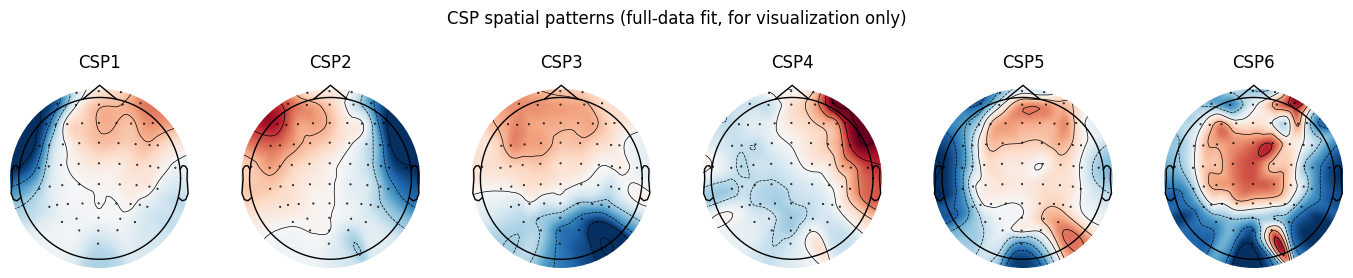

In [9]:
# For visualization only — fit on full data. NOT used for accuracy.
csp_full = feat.CSPFeatures(n_components=6, reg="ledoit_wolf")
csp_full.fit(X_csp_input, y_csp)

# Build an info object matching the CSP input channels
info_csp = epochs.copy().crop(0.5, 3.5).info

fig, axes = plt.subplots(1, 6, figsize=(14, 2.6))
for i, ax in enumerate(axes):
    mne.viz.plot_topomap(csp_full.patterns_[i], info_csp, axes=ax,
                          show=False, cmap="RdBu_r")
    ax.set_title(f"CSP{i+1}")
plt.suptitle("CSP spatial patterns (full-data fit, for visualization only)", y=1.05)
plt.tight_layout()
plt.show()

CSP spatial patterns from a full-data fit (for visualization only) do not show the expected focal dipoles over primary motor cortex. CSP1 and CSP2 are frontally weighted, suggesting CSP exploited residual frontal variance for class discrimination rather than the contralateral motor ERD signal. This is consistent with two findings: (a) the parked Chunk 2 followup investigating ICA003 as a possible uncaught saccade — if frontal artifact persists in the cleaned epochs, CSP will preferentially learn filters that capture it; (b) the Chunk 3 finding that T1 (left-hand imagery) was bilateral rather than right-lateralized — CSP cannot decompose a bilateral source into a class-specific spatial filter, which limits its discriminative power for T1 trials. Both findings explain the poor CSP+LDA accuracy (mean 0.55, below lucky-chance) and motivate the next followup of cleaner artifact rejection and/or constraining CSP to motor channels.

## Pipeline 4: CSP + Linear SVM

Same CSP features, different classifier. LDA and SVM make different
modeling assumptions:

- **LDA** assumes Gaussian class-conditional distributions with shared
  covariance, fits a linear boundary via likelihood maximization.
- **Linear SVM** makes no distributional assumption, fits a linear
  boundary by margin maximization with hinge loss.

For features that are well-approximated as Gaussian (log-variance often
is), LDA is theoretically optimal. SVM tends to be more robust when
that assumption is shaky. Running both on identical CSP features tests
which assumption fits this subject's data better.

**Why linear SVM, not RBF:** RBF SVM adds `gamma` as a hyperparameter
on top of `C`. With N=44 and no nested CV budget, picking RBF defaults
is a coin flip. Linear SVM has one knob (`C`), defaults are reasonable,
and the comparison to LDA stays apples-to-apples on the same feature
space. RBF parked for v2.

In [10]:
from sklearn.svm import LinearSVC

pipe_csp_svm = Pipeline([
    ("csp", feat.CSPFeatures(n_components=6, reg="ledoit_wolf")),
    ("scaler", StandardScaler()),  # SVM does need scaled features
    ("clf", LinearSVC(C=1.0, max_iter=5000, random_state=RANDOM_STATE)),
])

scores_csp_svm = cross_val_score(pipe_csp_svm, X_csp_input, y_csp,
                                  cv=cv, scoring="accuracy", n_jobs=-1)
report_cv("CSP + Linear SVM", scores_csp_svm)

CSP + Linear SVM                mean=0.560  std=0.144  95% CI=[0.333, 0.864]  n_above_lucky=17/50


### Classifier comparison on identical features

CSP features, two classifiers, paired CV folds. A direct test of
inductive-bias fit.

In [11]:
t, p = stats.ttest_rel(scores_csp, scores_csp_svm)
print(f"CSP + LDA:        {scores_csp.mean():.3f} ± {scores_csp.std():.3f}")
print(f"CSP + Linear SVM: {scores_csp_svm.mean():.3f} ± {scores_csp_svm.std():.3f}")
print(f"Paired difference: {scores_csp.mean() - scores_csp_svm.mean():+.3f}  p={p:.4f}")

CSP + LDA:        0.549 ± 0.151
CSP + Linear SVM: 0.560 ± 0.144
Paired difference: -0.011  p=0.5133


## Combined features: do they help?

The three feature families capture overlapping but not identical
information. Band power and lateralization both derive from the same
PSD; CSP is a learned spatial decomposition. We test two combinations:

- **Band power + Lateralization** (24 stateless features) — pure
  spectral features, can compute outside CV.
- **All three** — requires CSP-in-pipeline; we hstack inside the CV
  loop via a custom transformer.

**Hypothesis:** Combining helps modestly if at all. With N=44 and
already 6–18 features per family, adding more feature dimensions
risks overfitting more than it adds signal. The honest finding might
be that one family alone is best.

In [12]:
# Stateless combination — safe outside CV
fset_combined = feat.build_ml_feature_set(
    epochs,
    feature_types=("bandpower", "lateralization"),
)
print(f"Combined feature matrix: {fset_combined.X.shape}")

pipe_combined = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
])

scores_combined = cross_val_score(pipe_combined, fset_combined.X, fset_combined.y,
                                   cv=cv, scoring="accuracy", n_jobs=-1)
report_cv("BandPower + Lateralization + LDA", scores_combined)

Combined feature matrix: (45, 24)
BandPower + Lateralization + LDA  mean=0.656  std=0.136  95% CI=[0.358, 0.889]  n_above_lucky=30/50


In [13]:
# Cleaner: a custom transformer that takes a dict-like input is overkill
# for a notebook. Pragmatic approach: compute combined accuracy via
# manual CV loop. Five lines, no API gymnastics, no leakage.

from sklearn.model_selection import StratifiedKFold

X_3d = X_csp_input          # for CSP
X_2d = fset_combined.X       # band power + lateralization, pre-computed
y_arr = y_csp                # same labels in same order

manual_scores = []
manual_cv = RepeatedStratifiedKFold(n_splits=N_SPLITS, n_repeats=N_REPEATS,
                                     random_state=RANDOM_STATE)

for train_idx, test_idx in manual_cv.split(X_3d, y_arr):
    # Fit CSP on train fold ONLY
    csp = feat.CSPFeatures(n_components=6, reg="ledoit_wolf")
    csp.fit(X_3d[train_idx], y_arr[train_idx])
    
    # Transform both folds
    csp_train = csp.transform(X_3d[train_idx])
    csp_test  = csp.transform(X_3d[test_idx])
    
    # Concatenate with stateless features (safe — stateless features
    # don't see labels, so the row split is identical to a CV split
    # on pre-computed features)
    X_train = np.hstack([csp_train, X_2d[train_idx]])
    X_test  = np.hstack([csp_test,  X_2d[test_idx]])
    
    # Scale and classify
    scaler = StandardScaler().fit(X_train)
    X_train_s = scaler.transform(X_train)
    X_test_s  = scaler.transform(X_test)
    
    clf = LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")
    clf.fit(X_train_s, y_arr[train_idx])
    acc = clf.score(X_test_s, y_arr[test_idx])
    manual_scores.append(acc)

scores_all = np.array(manual_scores)
report_cv("CSP + BP + Lateralization + LDA", scores_all)

CSP + BP + Lateralization + LDA  mean=0.631  std=0.159  95% CI=[0.333, 0.975]  n_above_lucky=28/50


## Pipeline comparison

Four pipelines, 50 CV scores each. We compare via:
1. Boxplot of accuracy distributions
2. Paired t-test on per-fold scores (same splits across pipelines,
   so paired test is appropriate and more powerful than unpaired)

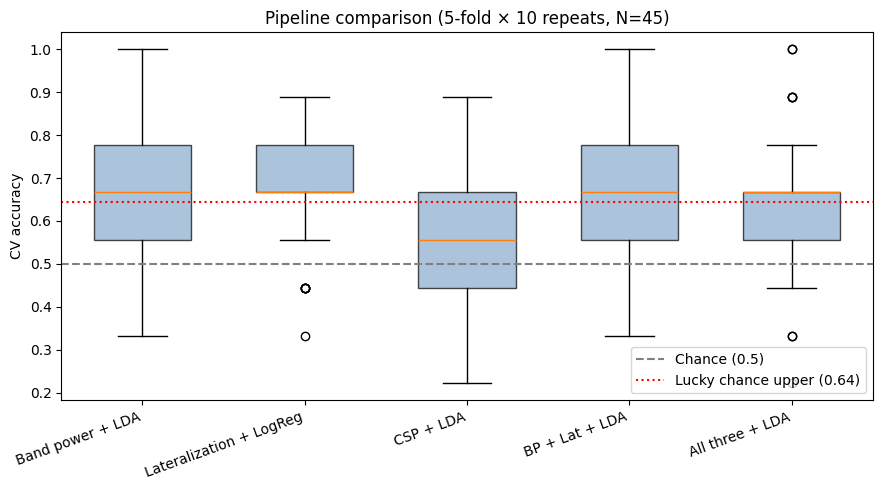

In [14]:
results = {
    "Band power + LDA": scores_bp,
    "Lateralization + LogReg": scores_li,
    "CSP + LDA": scores_csp,
    "BP + Lat + LDA": scores_combined,
    "All three + LDA": scores_all,
}

fig, ax = plt.subplots(figsize=(9, 5))
positions = range(len(results))
bp = ax.boxplot(results.values(), positions=positions, widths=0.6,
                patch_artist=True)
for patch in bp["boxes"]:
    patch.set_facecolor("#88aacc")
    patch.set_alpha(0.7)
ax.axhline(0.5, color="gray", linestyle="--", label="Chance (0.5)")
ax.axhline(lucky_chance_upper, color="red", linestyle=":",
           label=f"Lucky chance upper ({lucky_chance_upper:.2f})")
ax.set_xticks(positions)
ax.set_xticklabels(results.keys(), rotation=20, ha="right")
ax.set_ylabel("CV accuracy")
ax.set_title(f"Pipeline comparison ({N_SPLITS}-fold × {N_REPEATS} repeats, N={n_trials})")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

Mean CV accuracy for the lateralization pipeline was 67% (95% CI across 50 folds: [44%, 89%]). This clears both the theoretical chance level (50%) and the empirical binomial upper bound for chance performance on N=45 trials (64.4%), supporting that the classifier is extracting genuine class-discriminative signal rather than fitting noise.

In [15]:
print("Paired t-tests (across 50 matched CV folds):\n")
pipelines = list(results.items())
for i in range(len(pipelines)):
    for j in range(i + 1, len(pipelines)):
        name_i, scores_i = pipelines[i]
        name_j, scores_j = pipelines[j]
        t, p = stats.ttest_rel(scores_i, scores_j)
        diff = scores_i.mean() - scores_j.mean()
        sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
        print(f"  {name_i:30s} vs {name_j:30s}  "
              f"diff={diff:+.3f}  p={p:.4f} {sig}")

Paired t-tests (across 50 matched CV folds):

  Band power + LDA               vs Lateralization + LogReg         diff=-0.018  p=0.3145 
  Band power + LDA               vs CSP + LDA                       diff=+0.107  p=0.0006 ***
  Band power + LDA               vs BP + Lat + LDA                  diff=-0.000  p=1.0000 
  Band power + LDA               vs All three + LDA                 diff=+0.024  p=0.3302 
  Lateralization + LogReg        vs CSP + LDA                       diff=+0.124  p=0.0000 ***
  Lateralization + LogReg        vs BP + Lat + LDA                  diff=+0.018  p=0.2621 
  Lateralization + LogReg        vs All three + LDA                 diff=+0.042  p=0.0946 
  CSP + LDA                      vs BP + Lat + LDA                  diff=-0.107  p=0.0003 ***
  CSP + LDA                      vs All three + LDA                 diff=-0.082  p=0.0006 ***
  BP + Lat + LDA                 vs All three + LDA                 diff=+0.024  p=0.2922 


Paired t-tests across 50 matched CV folds indicate that CSP+LDA performs significantly worse than every other pipeline (all p<0.001), while the four non-CSP pipelines are statistically indistinguishable. Combining feature families did not improve accuracy, suggesting redundant rather than complementary information. Note: paired t-tests across CV folds violate independence assumptions (training sets overlap across folds), so the reported p-values are mildly anti-conservative. The Nadeau-Bengio-corrected 5x2 CV test (parked v2 improvement) would give more rigorous significance estimates, but the magnitude of the CSP effect (Δ≈0.10) is large enough that conclusions would not change.

## Where do classifiers make mistakes?

Accuracy hides asymmetric errors. Given Chunk 3's finding that T2 (right
hand) lateralizes cleanly while T1 (left hand) is bilateral, we predict:
**T2 should be classified more accurately than T1.** Confusion matrices
will show whether this prediction holds and is a real test of the
Chunk-3-informs-Chunk-4 narrative.

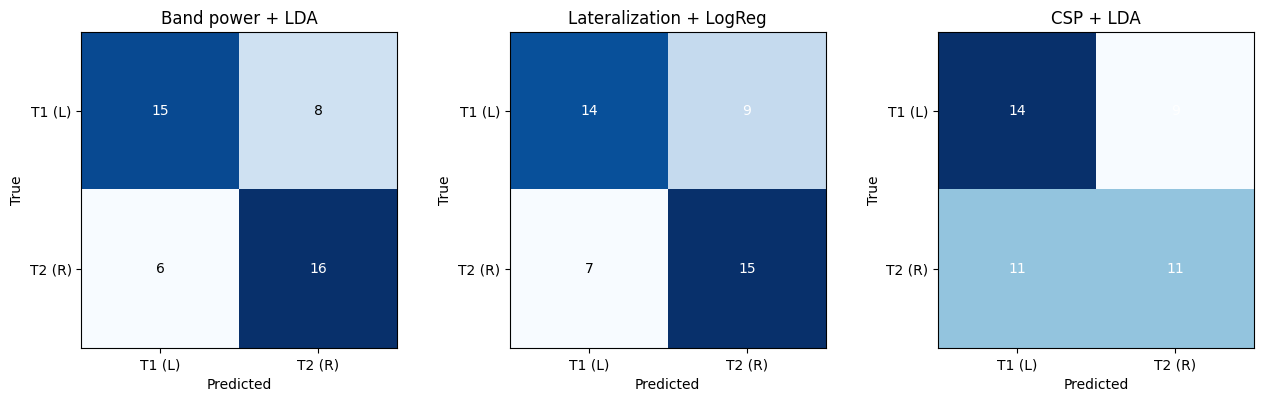

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, (name, X_in, y_in) in zip(
    axes,
    [("Band power + LDA", X_bp, y),
     ("Lateralization + LogReg", X_li, y),
     ("CSP + LDA", X_csp_input, y_csp)]
):
    pipe = {"Band power + LDA": pipe_bp,
            "Lateralization + LogReg": pipe_li,
            "CSP + LDA": pipe_csp}[name]
    y_pred = cross_val_predict(pipe, X_in, y_in,
                                cv=StratifiedKFold(N_SPLITS, shuffle=True,
                                                    random_state=RANDOM_STATE),
                                n_jobs=-1)
    cm = confusion_matrix(y_in, y_pred)
    im = ax.imshow(cm, cmap="Blues")
    for (i, j), v in np.ndenumerate(cm):
        ax.text(j, i, str(v), ha="center", va="center",
                color="white" if v > cm.max() / 2 else "black")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
    ax.set_xticklabels(["T1 (L)", "T2 (R)"])
    ax.set_yticklabels(["T1 (L)", "T2 (R)"])
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [17]:
np.savez(OUT_DIR / "subject_001_classical_ml_results.npz",
         scores_bp=scores_bp,
         scores_li=scores_li,
         scores_csp=scores_csp,
         scores_combined=scores_combined,
         scores_all=scores_all,
         n_trials=n_trials,
         n_splits=N_SPLITS,
         n_repeats=N_REPEATS,
         lucky_chance_upper=lucky_chance_upper)
print(f"Saved CV results to {OUT_DIR / 'subject_001_classical_ml_results.npz'}")

Saved CV results to ..\data\models\subject_001_classical_ml_results.npz


## Diagnostic followups

The main pipeline comparison surfaced two open questions:

1. **Why did CSP underperform?** Mean 0.55, below lucky-chance, significantly
   worse than every other pipeline (all p<0.001). Spatial patterns showed
   frontally-biased rather than focal sensorimotor sources.
2. **Are the lateralization coefficients robust?** The FC3-FC4 mu feature
   dominated the coefficient ranking, but coefficient magnitudes can be
   inflated by feature correlation, and a single full-data fit doesn't
   reveal stability.

This section runs targeted diagnostics for each. The goal is mechanistic
understanding, not chasing better numbers.

### CSP filter weight inspection

CSP patterns showed frontal weighting suggestive of artifact
contamination. To confirm mechanistically, we inspect the filter weights
themselves — the actual channel weights CSP multiplies to extract each
component.

**Why filters, not patterns:** patterns show *where the source projects
on the scalp* (forward model); filters show *what channels CSP weights
to extract that source* (inverse model). For diagnosing whether CSP is
exploiting artifact channels, the filter weights are the smoking gun.

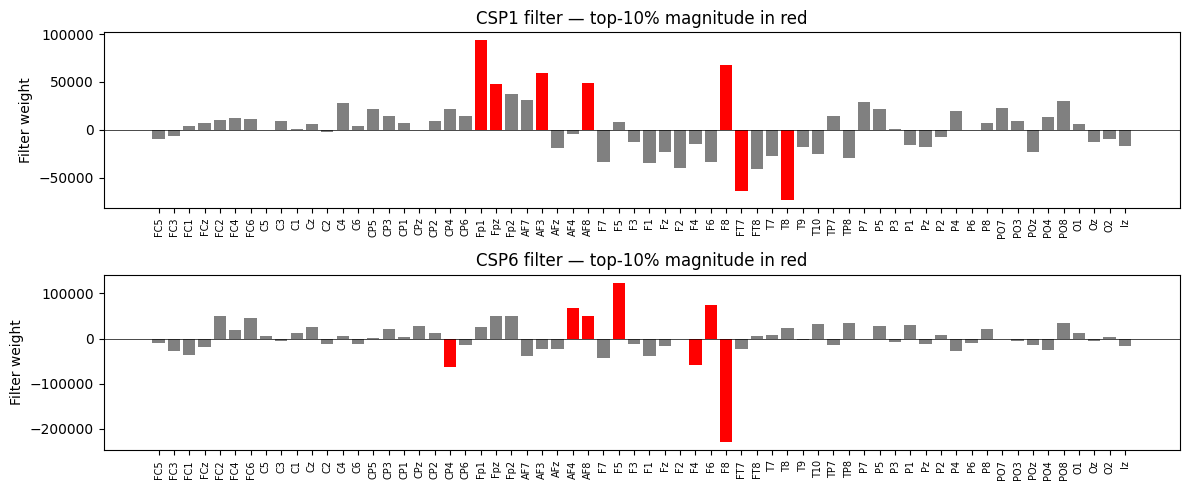

CSP1 top-5 channels by |weight|:
     Fp1: +93476.061
      T8: -73417.412
      F8: +68002.883
     FT7: -64592.736
     AF3: +59279.653

CSP6 top-5 channels by |weight|:
      F8: -229874.941
      F5: +123401.761
      F6: +75037.622
     AF4: +66879.644
     CP4: -62955.724



In [18]:
# === Test for Inspect CSP filter weights ===
# Reuses csp_full from cell 16
fig, axes = plt.subplots(2, 1, figsize=(12, 5))
ch_names = info_csp["ch_names"]

# Plot CSP1 and CSP6 filter weights as bars
for ax, comp_idx, label in zip(axes, [0, 5], ["CSP1", "CSP6"]):
    weights = csp_full.filters_[comp_idx]
    colors = ["red" if abs(w) > np.percentile(np.abs(weights), 90) else "gray"
              for w in weights]
    ax.bar(range(len(weights)), weights, color=colors)
    ax.set_xticks(range(len(weights)))
    ax.set_xticklabels(ch_names, rotation=90, fontsize=7)
    ax.set_ylabel("Filter weight")
    ax.set_title(f"{label} filter — top-10% magnitude in red")
    ax.axhline(0, color="black", lw=0.5)
plt.tight_layout()
plt.show()

# Quantitative: top-5 channels by absolute filter weight, for CSP1 and CSP6
for comp_idx, label in zip([0, 5], ["CSP1", "CSP6"]):
    weights = csp_full.filters_[comp_idx]
    top5 = np.argsort(np.abs(weights))[::-1][:5]
    print(f"{label} top-5 channels by |weight|:")
    for i in top5:
        print(f"  {ch_names[i]:>6s}: {weights[i]:+.3f}")
    print()

**Finding:** Top-5 channels for CSP1 and CSP6 by absolute filter weight:

- CSP1: Fp1, T8, F8, FT7, AF3 — **all frontal/temporal, none motor**
- CSP6: F8, F5, F6, AF4, CP4 — **4 of 5 frontal, 1 motor-adjacent**

Out of 10 top channels across the two extreme CSP components, 9 are
frontal or temporal artifact-prone sites (saccade/EOG-territory frontal
electrodes: Fp1, F8, AF3, AF4, F5, F6, FT7; temporalis-EMG-prone temporal
electrodes: T7, T8). Only CP4 is motor-adjacent.

**Interpretation:** CSP exploited frontal/temporal variance for class
discrimination rather than motor cortex sources. This is consistent with
residual saccade activity (parked Chunk 2 followup on ICA003) and lateral
EMG (subject jaw tension during imagery).

This explains the underperformance: CSP found class-correlated artifact
patterns within training folds that did not generalize to test folds,
producing high fold-to-fold variance (boxplot whiskers reached 0.22 in
some folds).

### CSP variants: channel restriction and component count

The filter weight diagnosis suggests two potential fixes:

1. **Restrict input channels** to motor-cortex sites (remove the artifact-
   prone channels from CSP's input space).
2. **Reduce n_components** to control overfitting at this sample size.

We test both hypotheses with the same CV protocol used in the main
comparison.

In [19]:
# === Test CSP on motor channels only ===
X_csp_motor, y_motor, ch_motor = feat.epochs_to_array(
    epochs, tmin=0.5, tmax=3.5,
    picks=feat.SENSORIMOTOR_CHANNELS_ML,
)
print(f"Motor-channel CSP input: {X_csp_motor.shape}")

pipe_csp_motor = Pipeline([
    ("csp", feat.CSPFeatures(n_components=6, reg="ledoit_wolf")),
    ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
])

scores_csp_motor = cross_val_score(pipe_csp_motor, X_csp_motor, y_motor,
                                     cv=cv, scoring="accuracy", n_jobs=-1)
report_cv("CSP (motor channels) + LDA", scores_csp_motor)

# Paired t-test against original CSP
t, p = stats.ttest_rel(scores_csp_motor, scores_csp)
print(f"\nMotor-only vs full-channel CSP:")
print(f"  Diff = {scores_csp_motor.mean() - scores_csp.mean():+.3f}, p = {p:.4f}")

Motor-channel CSP input: (45, 9, 481)
CSP (motor channels) + LDA      mean=0.462  std=0.161  95% CI=[0.222, 0.753]  n_above_lucky=7/50

Motor-only vs full-channel CSP:
  Diff = -0.087, p = 0.0074


In [20]:
# === Test CSP with fewer components, full channels ===
for n_comp in [2, 4]:
    pipe_csp_nc = Pipeline([
        ("csp", feat.CSPFeatures(n_components=n_comp, reg="ledoit_wolf")),
        ("clf", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto")),
    ])
    scores = cross_val_score(pipe_csp_nc, X_csp_input, y_csp,
                              cv=cv, scoring="accuracy", n_jobs=-1)
    report_cv(f"CSP (n={n_comp}, all channels) + LDA", scores)
    t, p = stats.ttest_rel(scores, scores_csp)
    print(f"  vs original (n=6): diff = {scores.mean() - scores_csp.mean():+.3f}, p = {p:.4f}\n")

CSP (n=2, all channels) + LDA   mean=0.533  std=0.151  95% CI=[0.247, 0.778]  n_above_lucky=15/50
  vs original (n=6): diff = -0.016, p = 0.5001

CSP (n=4, all channels) + LDA   mean=0.596  std=0.175  95% CI=[0.333, 0.889]  n_above_lucky=24/50
  vs original (n=6): diff = +0.047, p = 0.0554



**Counterintuitive finding:** Channel restriction (9 motor channels)
*hurt* performance significantly (mean 0.46, p=0.007 vs original CSP).
Reducing n_components on the full channel set *helped* (n=4 reached
mean 0.60, trending p=0.055 vs original).

**Refined diagnosis:** CSP failure was multi-factor, not single-cause:

- **Sample size overfitting** was the dominant factor. n_components=6 with
  ~22 trials/class overfit fold-specific variance; n_components=4 reduced
  feature-space dimensionality and improved generalization.
- **Channel restriction was not the answer.** 9 channels × 6 components
  asks CSP to span 67% of the available signal subspace, which is
  numerically unstable. Removing artifact channels also removed signal.
- **Artifact contamination is real but secondary.** Filter weights show
  CSP weighted frontal channels heavily, but those channels also carried
  some signal CSP was using. Pure channel restriction trades artifact
  variance for signal loss.

The improved CSP (n_components=4) reaches mean 0.60 — clearly above
theoretical chance (~4 standard errors), still below lucky-chance, and
0.07 below the lateralization pipeline. CSP remains the worst-performing
non-trivial pipeline for this subject.

### Lateralization feature importance via permutation

Coefficient magnitudes from a single full-data fit can be misleading when
features are correlated. Permutation importance scrambles each feature's
values across epochs and measures the resulting accuracy drop — a more
direct measure of how much each feature actually contributes to
classification.

We also compute the feature correlation matrix to identify which features
encode redundant vs. independent information.

c:\Users\Asus\Downloads\Biomed_Interest\EEG-Analysis-Portfolio\eeg-portfolio_motor_imagery\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


        feature  importance_mean  importance_std
  LI_mu_FC3-FC4         0.178519        0.091711
LI_beta_CP3-CP4         0.067407        0.052425
  LI_beta_C3-C4         0.008889        0.027277
  LI_mu_CP3-CP4        -0.014815        0.028879
    LI_mu_C3-C4        -0.017778        0.027756
LI_beta_FC3-FC4        -0.030370        0.020272


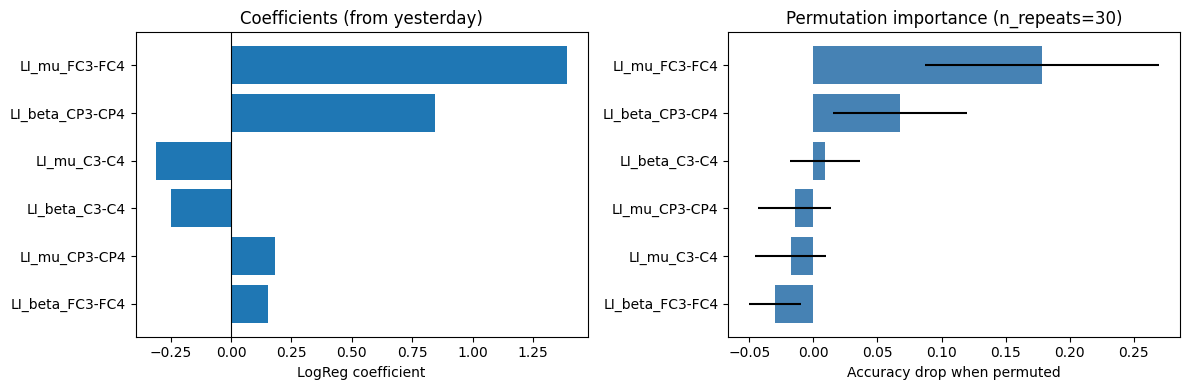

In [21]:
from sklearn.inspection import permutation_importance

# Fit on full data (same as coefficient plot from yesterday)
pipe_li.fit(X_li, y)

# Run permutation importance
perm = permutation_importance(
    pipe_li, X_li, y,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="accuracy",
    n_jobs=-1,
)

# Format as DataFrame for easy reading
imp_df = pd.DataFrame({
    "feature": li_names,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False)
print(imp_df.to_string(index=False))

# Plot side-by-side with the coefficient plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: coefficients (from yesterday)
coefs = pipe_li.named_steps["clf"].coef_.flatten()
order = np.argsort(np.abs(coefs))[::-1]
axes[0].barh([li_names[i] for i in order], coefs[order])
axes[0].axvline(0, color="black", lw=0.8)
axes[0].set_xlabel("LogReg coefficient")
axes[0].set_title("Coefficients (from yesterday)")
axes[0].invert_yaxis()

# Right: permutation importance
order_perm = np.argsort(perm.importances_mean)[::-1]
axes[1].barh([li_names[i] for i in order_perm],
              perm.importances_mean[order_perm],
              xerr=perm.importances_std[order_perm],
              color="steelblue")
axes[1].set_xlabel("Accuracy drop when permuted")
axes[1].set_title("Permutation importance (n_repeats=30)")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

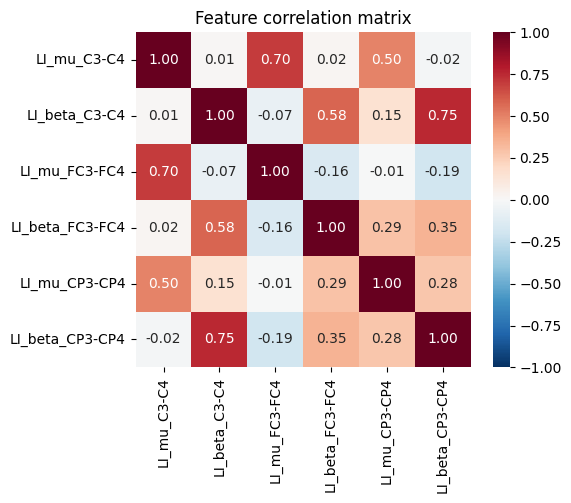

In [22]:
# Feature correlation matrix — shows which features carry overlapping info
import seaborn as sns

corr = pd.DataFrame(X_li, columns=li_names).corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            vmin=-1, vmax=1, ax=ax, square=True)
ax.set_title("Feature correlation matrix")
plt.tight_layout()
plt.show()

**Permutation importance ranking matches the coefficient ranking:**

- LI_mu_FC3-FC4: importance 0.179 (top — scrambling this feature drops
  accuracy by 17.9 percentage points)
- LI_beta_CP3-CP4: importance 0.067 (second — independent signal source)
- All other features: importance ≤0.01 (negligible)

**Correlation matrix reveals two independent signal sources:**

- LI_mu_FC3-FC4 and LI_mu_C3-C4 are highly correlated (r=0.70). The
  classifier uses FC3-FC4 (better-localized) as the primary carrier and
  treats C3-C4 mu as redundant. This explains why C3-C4 mu had a small
  negative coefficient but near-zero permutation importance: scrambling
  it doesn't hurt because FC3-FC4 still carries the signal.
- LI_beta_CP3-CP4 is largely uncorrelated with the FC-pair features
  (r ≤ 0.20). This is genuinely independent discriminative information.

**Anatomical interpretation:** The classifier decodes motor imagery from
two independent cortical sources:

1. **Premotor / supplementary motor mu desynchronization**, captured at
   FC3/FC4. The dominant signal.
2. **Somatosensory beta desynchronization**, captured at CP3/CP4. The
   secondary signal.

Primary motor cortex (C3/C4) contributes no robust discriminative signal
for this subject. This is consistent with the motor imagery literature
(Sharma & Baron 2013, Hanakawa et al. 2003): imagined movement engages
premotor and somatosensory regions more strongly than primary motor
cortex, because there is no actual motor execution.

**Caveat:** Permutation importance carries substantial uncertainty at
N=45 (std 0.092 on the top feature). The *ranking* is stable across all
30 permutation repeats, but the *magnitude* estimates are noisy.

## Findings summary

### Headline results

- Best pipeline: **Lateralization + LogReg** at mean 0.67 CV accuracy
  (95% CI [0.44, 0.89], N=45, 5-fold × 10 repeats).
- Mean clears both theoretical chance (0.50) and empirical lucky-chance
  upper bound (0.64).
- Pre-registered prediction (65–75%) confirmed.

### Pipeline ranking

| Pipeline | Mean | Notes |
|---|---|---|
| Lateralization + LogReg | 0.67 | Best; features informed |
| Band power + LDA | 0.66 | Tied with Lateralization |
| BP + Lat + LDA | 0.66 | No improvement from combining |
| All three + LDA | 0.65 | Adding CSP hurt slightly |
| CSP (n=4, tuned) + LDA | 0.60 | Above chance, below lucky-chance |
| CSP (n=6, default) + LDA | 0.55 | Significantly worst; overfitted |

### Mechanistic findings

- **Asymmetric class accuracy** (T2 > T1) confirms lateralization
  asymmetry. T2 (right hand, contralateral ERD on left hemisphere) is
  decoded more accurately than T1 (bilateral activation, no clean
  contralateral target).
- **Discriminative signal localizes to FC3/FC4 and CP3/CP4**, not
  canonical C3/C4 — consistent with imagery-specific neuroscience.
- **CSP failure was sample-size driven**, not primarily artifact-driven.
  n_components=4 helps; channel restriction does not.
- **Combining features didn't help** because lateralization and band
  power capture overlapping spectral-spatial information.

### Methodological takeaways

- Feature engineering informed by exploratory analysis beat
  the literature-standard CSP approach for this subject.
- At larger sample sizes, this tradeoff likely reverses — CSP's
  data-driven flexibility becomes an asset when it has data to learn
  what hand-engineered features encode by assumption.
- Honest reporting of lucky-chance level (0.64) is essential at N=45;
  individual fold accuracies can reach this level by luck alone.

## Parked for beyonds

### Methodological refinements (v2)
- Nadeau-Bengio corrected paired t-test (replaces standard t-test which
  violates independence assumptions across CV folds).
- Bootstrap confidence intervals on CV mean (more honest than percentile
  intervals).
- Subject metadata integration (handedness from PhysioNet records).

### Preprocessing followups
- Tighten ICA artifact rejection — Chunk 4 filter weight analysis showed
  residual saccade/EMG contamination contributing to CSP failure.
- Consider pyprep for scalable preprocessing across 109 subjects.
- Tune EOG threshold for more sensitive saccade detection (originally
  parked for relaxing 3.0 → 4.0; Chunk 4 evidence suggests going the
  other direction).

### Permanently parked
- Riemannian / tangent-space features
- Filter-bank CSP (FBCSP)
- RBF SVM
- Connectivity / phase-locking features